<a href="https://colab.research.google.com/github/nightsky18/Aprendizaje-de-maquinas/blob/main/Cuaderno_2_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##***Flujo del proyecto***
1. Análisis exploratorio de los datos (EDA)
2. Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas
3. Entrenamiento de los modelos: Cuantos? Cuáles? --> Depende de las métricas
4. Evaluación: Comparar métricas
5. Tunning de hiperparámetros
6. Modelo final --> Producción


##Análisis Exploratorio


###1. Importar los datos

In [1]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn import preprocessing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


In [2]:
# Configuración de estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

In [3]:
#. Carga del dataset Wine
wine= load_wine()

df= pd.DataFrame(data= wine.data, columns= wine.feature_names)
df['target'] = wine.target
df['target_name']= df['target'].map({i: name for i, name in enumerate(wine.target_names)}) #compresión de expresiones

print("Dataset: Wine")
print(f'Muestras: {df.shape[0]}') #es el número de filas, es decir, el número de muestras/instancias -# registros
print(f'Características: {df.shape[1]-2}') #Dimensiones columnas -# No necesito target ni indice
print(f'Clases: {list(wine.target_names)}')
print(f'Descripción: {wine.DESCR[:500]}')
#


Dataset: Wine
Muestras: 178
Características: 13
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Descripción: .. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0


###2. Análisis

In [4]:
df_data = df.describe().T
df_data

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Análisis exploratorio de los datos

In [5]:

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [6]:
df.describe(include='all').round(2) #c

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class_1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89,0.94,NaN
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91,0.78,NaN
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00,0.00,NaN
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50,0.00,NaN
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50,1.00,NaN
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00,2.00,NaN


In [7]:
# Datos faltantes
print(df.isnull().sum().to_string())


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


In [8]:
print(df.isna().sum().to_string())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0


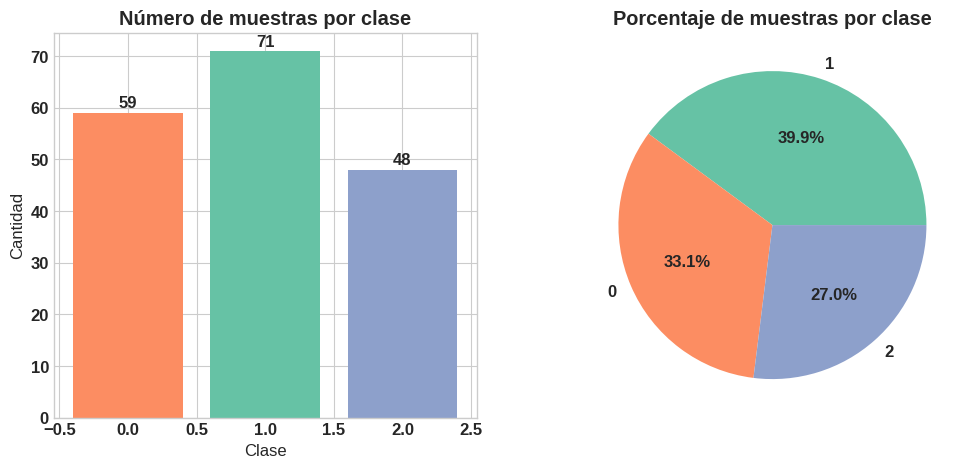

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
class_counts = df['target'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Número de muestras por clase', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(class_counts.values):
    #axes[0].text(i, v +1 , str(v), ha='center', fontweight='bold')
    axes[0].text(class_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(class_counts)))
axes[1].set_title('Porcentaje de muestras por clase', fontweight='bold')

plt.show()

### Qué se espera
 Se espera obtener 6 histogramas, uno por cada característica seleccionada, y dentro de cada histograma ver superpuestas las distribuciones de las distintas clases de vino. Al observarlos, lo ideal es detectar variables donde las clases se separen visualmente, porque esas variables suelen aportar más información al modelo de clasificación

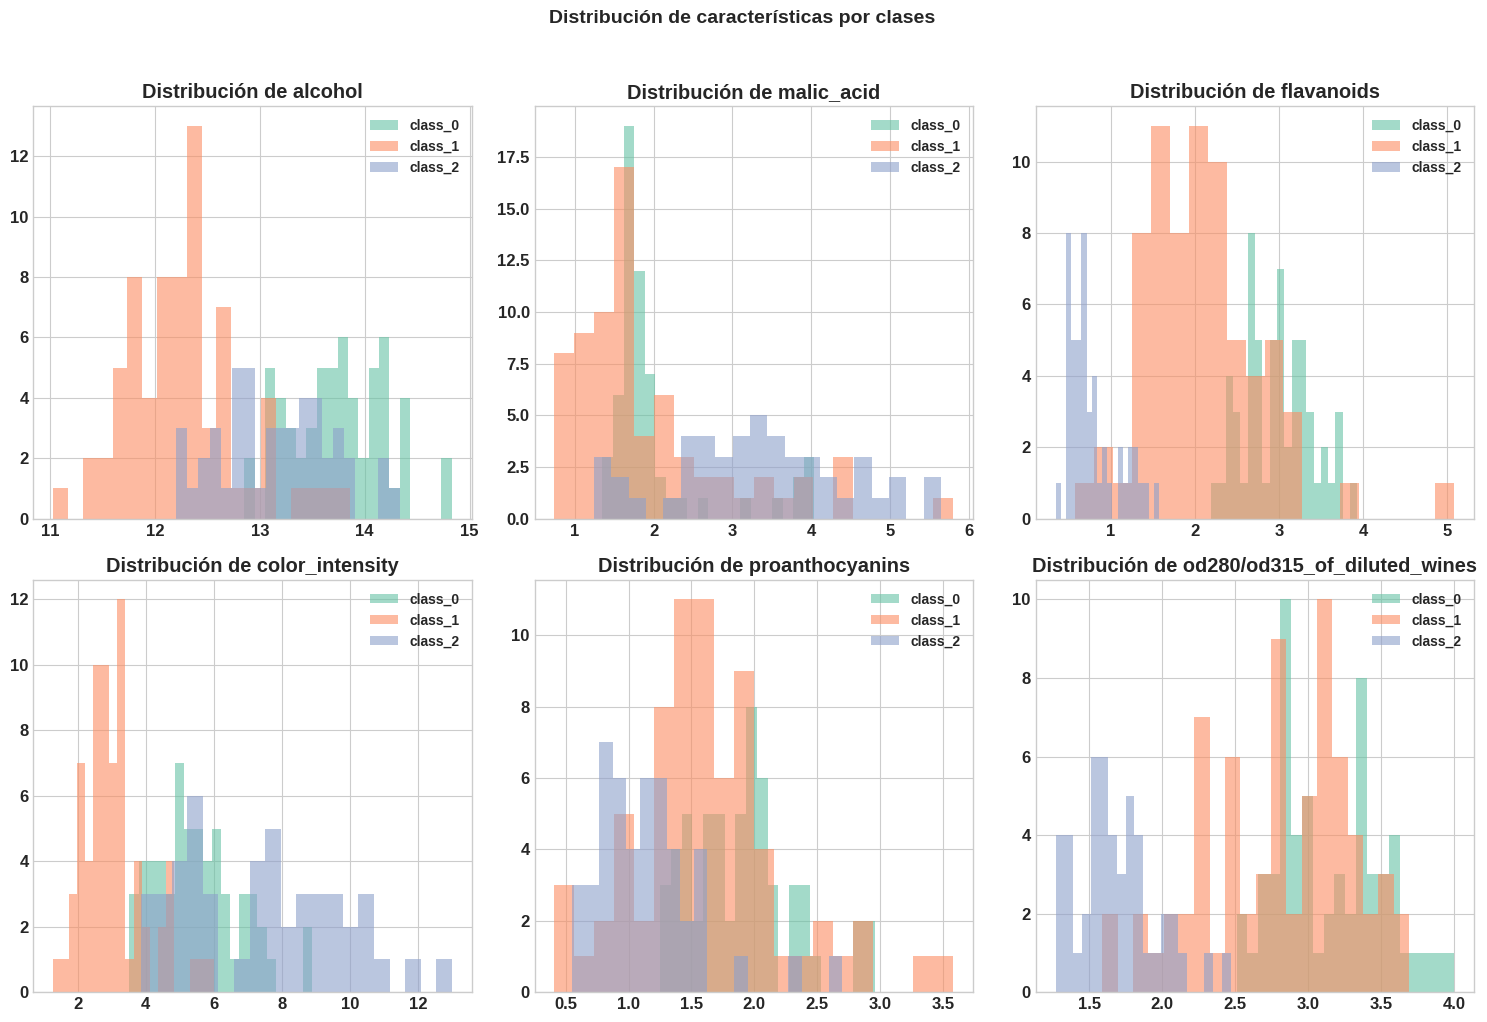

In [10]:
#Distribución de caracteristicas o feature por clases
feature_to_plot= ['alcohol', 'malic_acid','flavanoids',
                    'color_intensity', 'proanthocyanins','od280/od315_of_diluted_wines' ] # lista con los nombres de las variables que se quieren graficar
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()

for i, feature in enumerate(feature_to_plot):
  for cls in wine.target_names:
    subset= df[df['target_name']== cls][feature]
    axes[i].hist(subset, bins=20, alpha=0.6, label=cls)
  axes[i].set_title(f'Distribución de {feature}', fontweight='bold')
  axes[i].legend(fontsize=10)

plt.suptitle('Distribución de características por clases', fontsize=14, fontweight='bold', y= 1.02)
plt.tight_layout()
plt.show()

Se espera ver una tabla con las mismas columnas del dataset original de características, pero ya transformadas. Los valores ya no serán números como 13.2 o 1065, sino valores positivos y negativos cercanos a 0. Eso significa cuanto está ese registro por debajo o encima de la media de esa característica.

In [11]:
from sklearn.preprocessing import StandardScaler

x_scaled = pd.DataFrame(StandardScaler().fit_transform(df[wine.feature_names]),
                        columns=wine.feature_names)
x_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


El tamaño de la caja (IQR): Representa el 50% de los datos. Si la caja es muy alta, hay mucha dispersión en los valores medios.
​
Los bigotes (líneas verticales): Muestran el límite teórico de los datos normales.
​
Los puntos sueltos: son los outliers,  indican qué variables tienen mediciones atípicas a vigilar

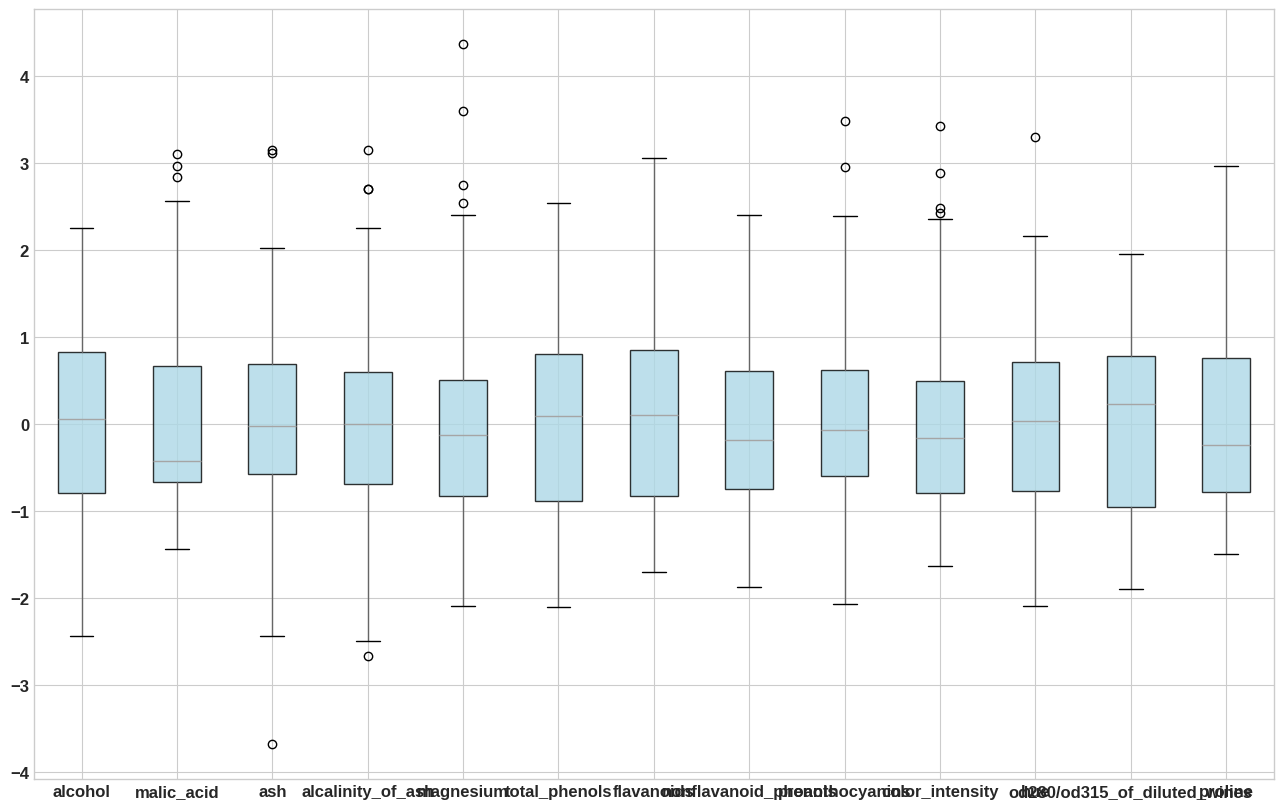

In [12]:
fig, ax= plt.subplots(figsize=(16,10))
x_scaled.boxplot(ax= ax, vert=True,patch_artist=True, boxprops = dict(facecolor='lightblue', alpha =0.8))
plt.show()

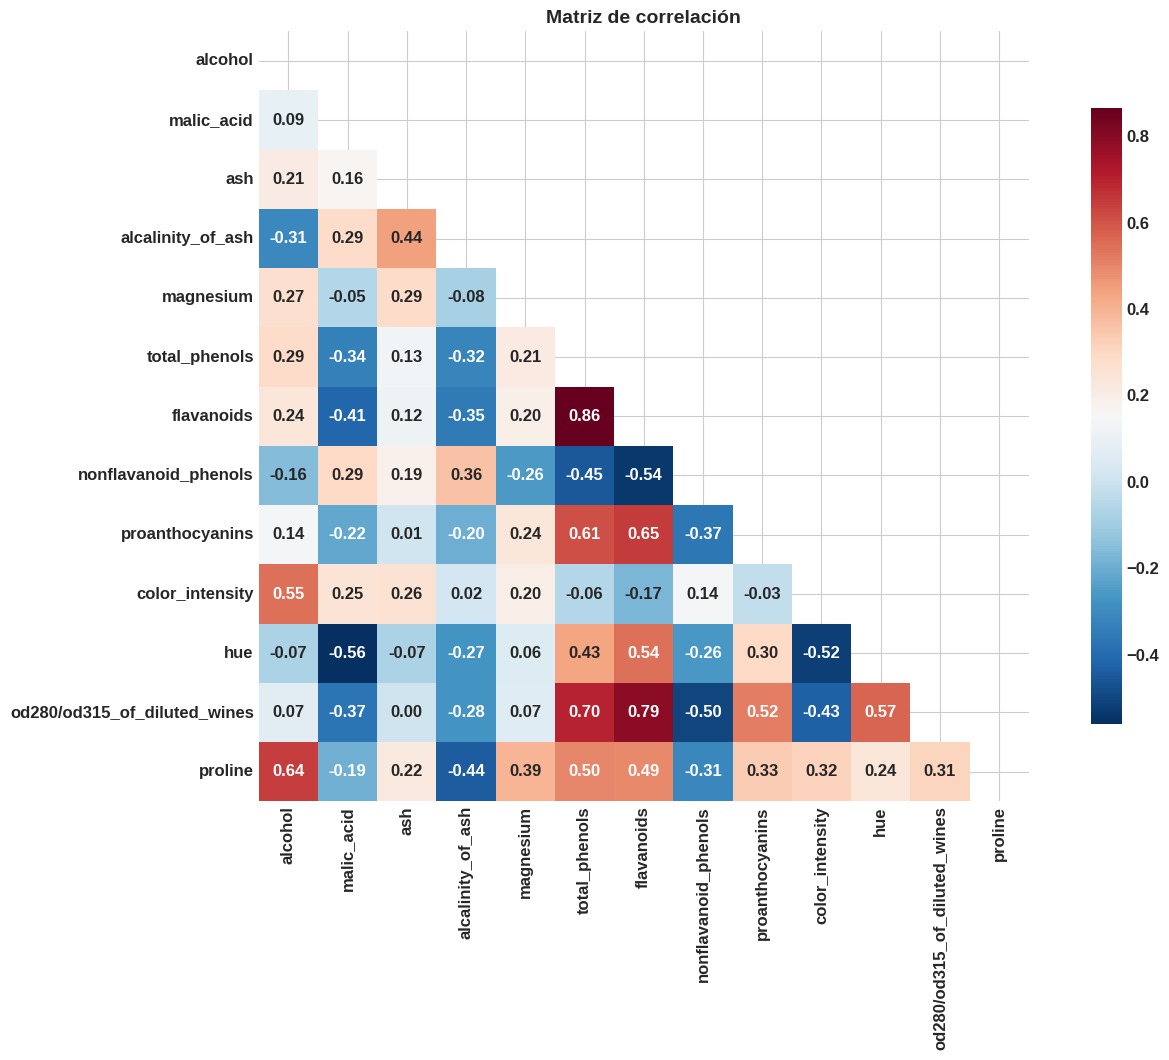

In [13]:
fig, ax= plt.subplots(figsize=(16,10))
corr= df[wine.feature_names].corr()
mask= np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True,mask=mask, fmt='.2f', cmap='RdBu_r', ax=ax, cbar_kws={'shrink':0.8}, square= True)
ax.set_title('Matriz de correlación', fontweight='bold', fontsize= 14)
plt.show()
#Identificar colinealidad
#Multicolinealidad - (<-80 o >80 Correlación muy alta) --redundante--

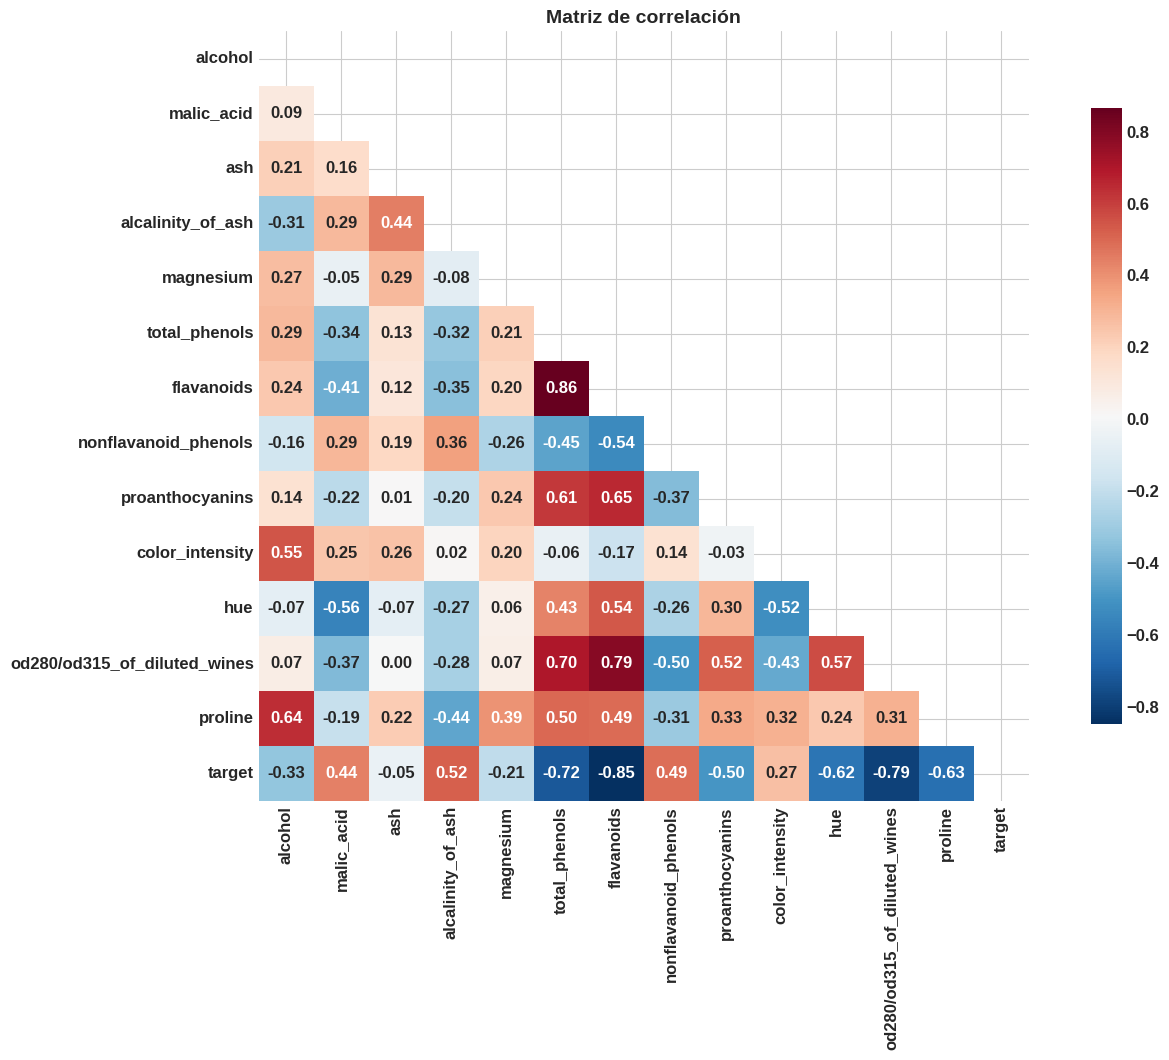

In [19]:
#Relación puntual de los datos
fig, ax= plt.subplots(figsize=(16,10))
corr= df[wine.feature_names + ['target']].corr()
mask= np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True,mask=mask, fmt='.2f', cmap='RdBu_r', ax=ax, cbar_kws={'shrink':0.8}, square= True)
ax.set_title('Matriz de correlación', fontweight='bold', fontsize= 14)
plt.show()

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X= df[wine.feature_names].values #solo columnas
y= df['target'].values

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)

print(f'Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Entrenamiento: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'Distribución de entrenamiento: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribución de prueba: {dict(zip(*np.unique(y_test, return_counts=True)))}')




Entrenamiento: 142 muestras (80%)
Entrenamiento: 36 muestras (20%)
Distribución de entrenamiento: {np.int64(0): np.int64(47), np.int64(1): np.int64(57), np.int64(2): np.int64(38)}
Distribución de prueba: {np.int64(0): np.int64(12), np.int64(1): np.int64(14), np.int64(2): np.int64(10)}


In [15]:
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

print("Datos escalados con standard scaler")
print(f'Media: {X_train_scaled.mean():.6f}') #si está bien tiende a 0
print(f'Desviación estándar: {X_train_scaled.std():.6f}') #tiende a 1
#

Datos escalados con standard scaler
Media: 0.000000
Desviación estándar: 1.000000


Entrenamientos y comparación de modelos


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [63]:
modelos= {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=39),
    'Árbol de decisión': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=5),
    'AdaBoost': AdaBoostClassifier(n_estimators=100,random_state=5, algorithm='SAMME'),
    'MLP Red Neuronal': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=5)
}

print(f'Cantidad de modelos: {len(modelos)}')
#Consultar modelos de ensable

Cantidad de modelos: 9


In [122]:
#Validación cruzada
resultados=[]

print('*'*80)
print(f"{'Modelo':<25}{'CV Accurancy (mead+-stf)':<25}{'Test accuracy':<15}{'F1 Macro'}")
print('*'*80)

for nombre, modelo in modelos.items():
  cv_scores= cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='accuracy')
  modelo.fit(X_train_scaled, y_train)
  y_pred= modelo.predict(X_test_scaled)
  test_accuracy= accuracy_score(y_test, y_pred)
  f1= f1_score(y_test, y_pred, average='macro')

  resultados.append(
      {
          'Modelo': nombre,
          'CV_Mean': cv_scores.mean(),
          'CV_STD': cv_scores.std(),
          'Test Accuracy': test_accuracy,
          'F1 Macro': f1
      }
  )

  print(f'{nombre:<25}{cv_scores.mean():<12.4f} +- {cv_scores.std():<12.4f}{test_accuracy:<15.4f}{ f1:<12.4f}')
print('*'*80)

  ##Mirar accurancy


********************************************************************************
Modelo                   CV Accurancy (mead+-stf) Test accuracy  F1 Macro
********************************************************************************
Regresión Logística      0.9860       +- 0.0172      0.9722         0.9718      
KNN                      0.9655       +- 0.0534      0.9722         0.9743      
SVM                      0.9793       +- 0.0276      1.0000         1.0000      
Árbol de decisión        0.9374       +- 0.0591      0.8056         0.8114      
Naive Bayes              0.9719       +- 0.0141      1.0000         1.0000      
Random Forest            0.9648       +- 0.0391      0.9722         0.9743      
Gradient Boosting        0.9224       +- 0.0645      0.9167         0.9202      
AdaBoost                 0.9791       +- 0.0277      0.8611         0.8649      
MLP Red Neuronal         0.9788       +- 0.0285      1.0000         1.0000      
***********************************

In [123]:
df_resultados= pd.DataFrame(resultados).sort_values(by= 'Test Accuracy', ascending=False)
df_resultados= df_resultados.reset_index(drop=True)
print("Ranking de los modelos por Test accuracy")
df_resultados


Ranking de los modelos por Test accuracy


,Modelo,CV_Mean,CV_STD,Test Accuracy,F1 Macro
0,SVM,0.979310,0.027586,1.000000,1.000000
1,MLP Red Neuronal,0.978818,0.028452,1.000000,1.000000
2,Naive Bayes,0.971921,0.014050,1.000000,1.000000
3,Regresión Logística,0.985961,0.017199,0.972222,0.971781
4,KNN,0.965517,0.053420,0.972222,0.974321
5,Random Forest,0.964778,0.039128,0.972222,0.974321
6,Gradient Boosting,0.922414,0.064521,0.916667,0.920196
7,AdaBoost,0.979064,0.027713,0.861111,0.864938
8,Árbol de decisión,0.937438,0.059100,0.805556,0.811353


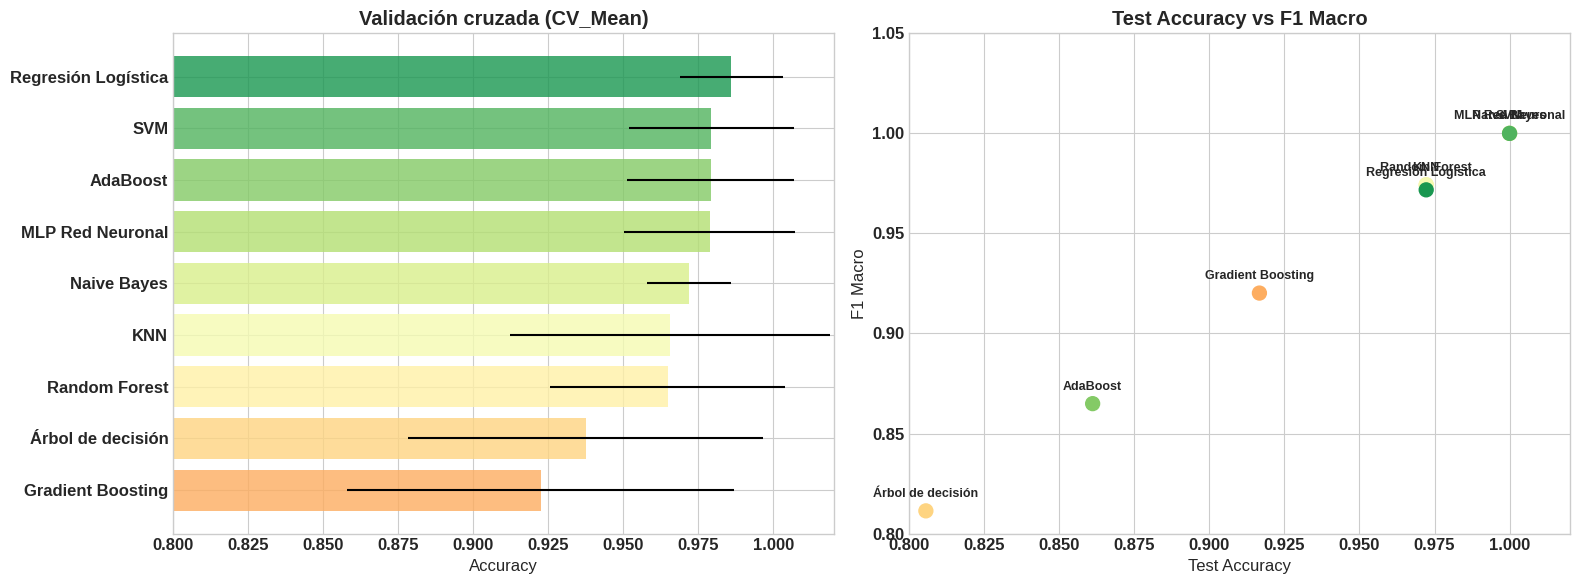

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df_resultados.sort_values('CV_Mean')
colors= plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_plot)))

axes[0].barh(df_plot['Modelo'], df_plot['CV_Mean'], xerr=df_plot['CV_STD'], color=colors, alpha=0.8)

axes[0].set_xlim(0.80, 1.02)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Validación cruzada (CV_Mean)', fontweight='bold')

axes[1].scatter(df_plot['Test Accuracy'], df_plot['F1 Macro'], color=colors, s=100, zorder=5)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_ylabel('F1 Macro')
axes[1].set_title('Test Accuracy vs F1 Macro', fontweight='bold')
axes[1].set_xlim(0.80, 1.02)
axes[1].set_ylim(0.80, 1.05)
for i, row in df_resultados.iterrows():
  # Corrected annotate usage for readability
  axes[1].annotate(row['Modelo'], (row['Test Accuracy'], row['F1 Macro']), fontsize=9,  ha='center',va='bottom', xytext=(0,8), textcoords='offset points' )

plt.tight_layout()
plt.show()
#

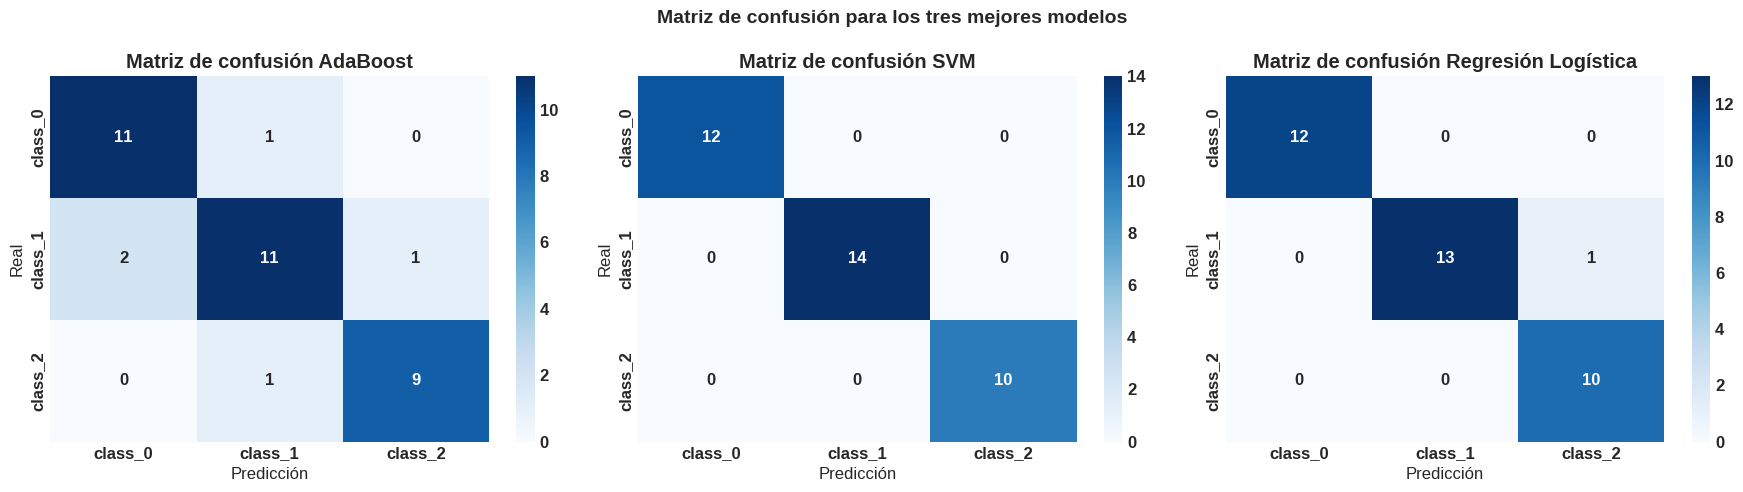

In [96]:
top_3 =df_resultados.sort_values('CV_Mean').tail(3)['Modelo'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre in zip(axes, top_3):
  modelo= modelos[nombre]
  y_pred= modelo.predict(X_test_scaled)
  cm= confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=wine.target_names, yticklabels=wine.target_names)

  ax.set_title(f'Matriz de confusión {nombre}', fontweight='bold')
  ax.set_ylabel('Real')
  ax.set_xlabel('Predicción')
plt.suptitle('Matriz de confusión para los tres mejores modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()